#Diabetes Prediction Model💉


#01- Importing Libraries

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [78]:
# Load teh dataset

df = pd.read_csv("/content/diabetes_prediction_dataset.csv")

In [79]:
# # Display the first few rows of the dataset
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [80]:
# Check for missing values
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [81]:
# Basic statistics of the dataset

df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [82]:
# check basic information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [83]:
# check duplicate values
print(df.duplicated().sum())

3854


In [84]:
# remove duplicate values
df = df.drop_duplicates()
print("______Removed Duplicate______")
print(df.duplicated().sum())

______Removed Duplicate______
0


# EDA

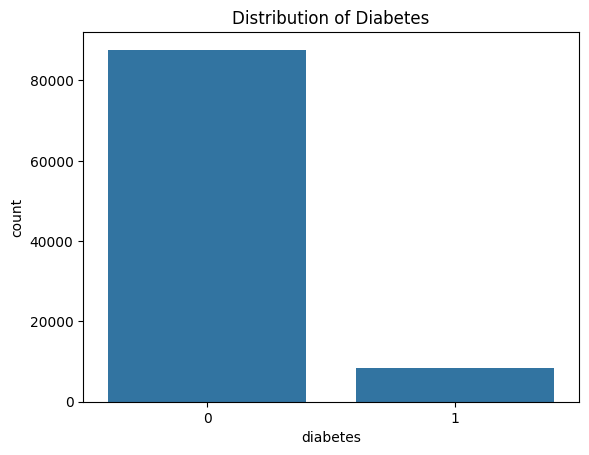

In [85]:
# Countplot for target variable
sns.countplot(x='diabetes',data=df)
plt.title("Distribution of Diabetes")
plt.show()

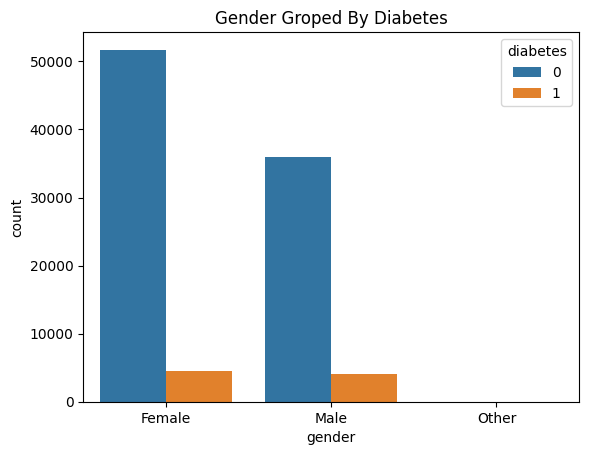

In [86]:
# Plot gender grouped by diabetes
sns.countplot(x='gender', hue='diabetes' , data=df)
plt.title("Gender Groped By Diabetes")
plt.show()

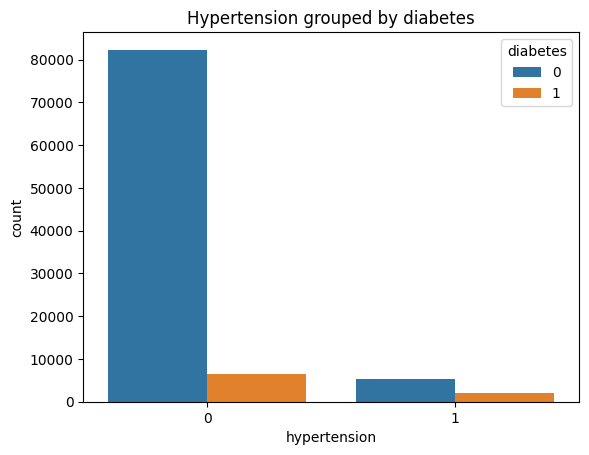

In [87]:
# Plot hypertension grouped by diabetes

sns.countplot(x='hypertension', hue='diabetes', data=df)
plt.title("Hypertension grouped by diabetes")
plt.show()

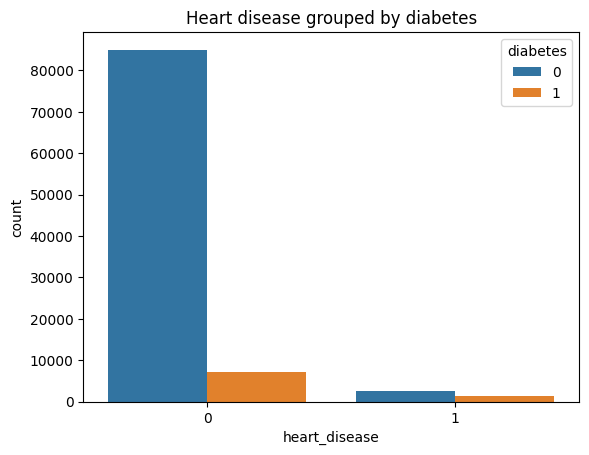

In [88]:

# Plot heart disease grouped by diabetes
sns.countplot(x="heart_disease", hue='diabetes', data=df)
plt.title("Heart disease grouped by diabetes")
plt.show()

In [89]:
# Calculate minimum, maximum, and average age
min_age  = df['age'].min()
max_age = df['age'].max()
avg_age = df['age'].mean()

# Print the results
print("Minimum Age:", min_age)
print("Maximum Age:", max_age)
print(f"Average Age: {avg_age}")


Minimum Age: 0.08
Maximum Age: 80.0
Average Age: 41.79432571297817


In [90]:
# Count of individuals with and without diabetes
diabetes_counts = df['diabetes'].value_counts()

print("Diabetes Counts:")
print(diabetes_counts)

Diabetes Counts:
diabetes
0    87664
1     8482
Name: count, dtype: int64


In [91]:
# Group by diabetes status and calculate min and max ages
grouped_ages = df.groupby('diabetes')['age'].agg(['min', 'max'])

In [92]:

print("Age Statistics by Diabetes Status:")
print(grouped_ages)

Age Statistics by Diabetes Status:
           min   max
diabetes            
0         0.08  80.0
1         3.00  80.0


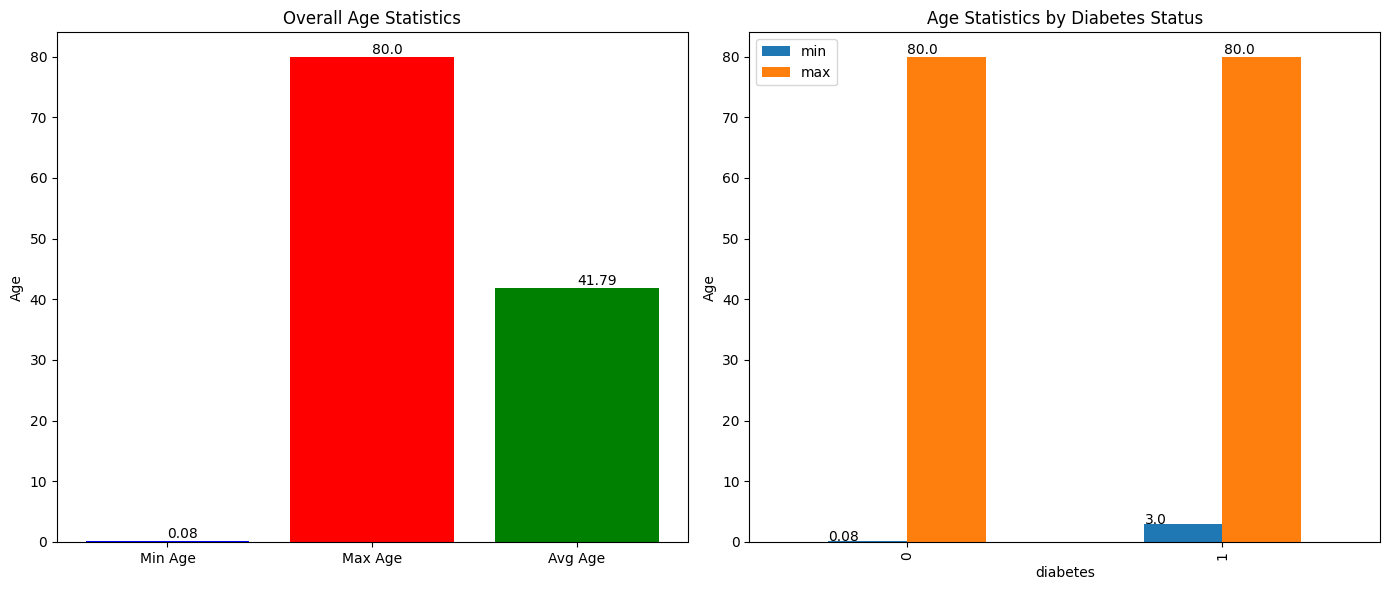

In [93]:
# Plotting
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Plot for overall min, max, and average age
bars = ax[0].bar(['Min Age', 'Max Age', 'Avg Age'], [min_age, max_age, avg_age], color=['blue', 'red', 'green'])
ax[0].set_title('Overall Age Statistics')
ax[0].set_ylabel('Age')

# Annotate bars with their values
for bar in bars:
    yval = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), va='bottom')  # Add text to the top of the bars

# Plot for min and max ages grouped by diabetes status
grouped_bars = grouped_ages.plot(kind='bar', ax=ax[1])
ax[1].set_title('Age Statistics by Diabetes Status')
ax[1].set_ylabel('Age')

# Annotate bars with their values
for p in grouped_bars.patches:
    grouped_bars.annotate(str(p.get_height()), (p.get_x() * 1.005, p.get_height() * 1.005))

plt.tight_layout()
plt.show()


In [94]:
# Diabetes & Smoking History
cross_table = pd.crosstab(df['diabetes'], df['smoking_history'])
print(cross_table)

smoking_history  No Info  current  ever  former  never  not current
diabetes                                                           
0                  31442     8249  3526    7709  31061         5677
1                   1445      948   472    1590   3337          690


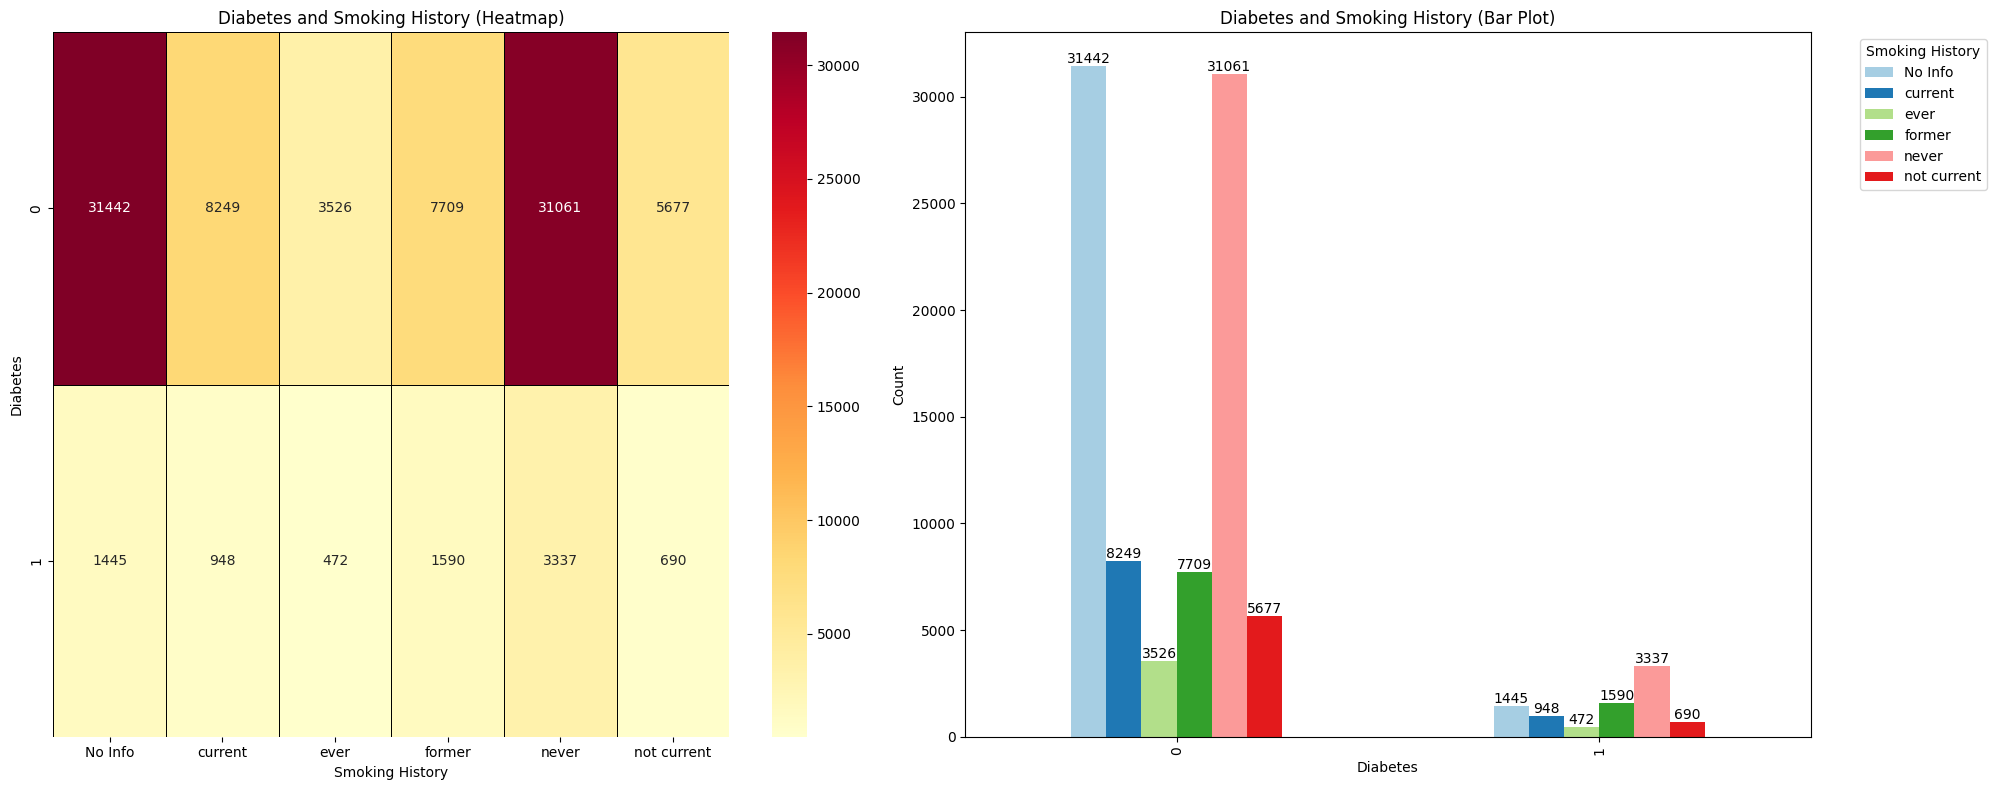

In [95]:
# Create subplots
fig, ax = plt.subplots(1, 2, figsize=(20, 8))

# Plotting the cross table as a heatmap
sns.heatmap(cross_table, cmap='YlOrRd', annot=True, fmt='d', linewidths=0.5, linecolor='black', ax=ax[0])
ax[0].set_title('Diabetes and Smoking History (Heatmap)')
ax[0].set_xlabel('Smoking History')
ax[0].set_ylabel('Diabetes')

# Plotting the cross table with separate bars for smoking history
cross_table.plot(kind='bar', stacked=False, ax=ax[1], color=plt.cm.Paired.colors)
ax[1].set_title('Diabetes and Smoking History (Bar Plot)')
ax[1].set_xlabel('Diabetes')
ax[1].set_ylabel('Count')
ax[1].legend(title='Smoking History', bbox_to_anchor=(1.05, 1), loc='upper left')

# Annotate bars with their values
for container in ax[1].containers:
    ax[1].bar_label(container)

plt.tight_layout()
plt.show()

# Encode Data

In [96]:
#removing un-wanted column
df.drop('smoking_history',axis=1,inplace=True)

In [97]:
# incode the data
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])
# df['smoking_history'] = le.fit_transform(df['smoking_history'])

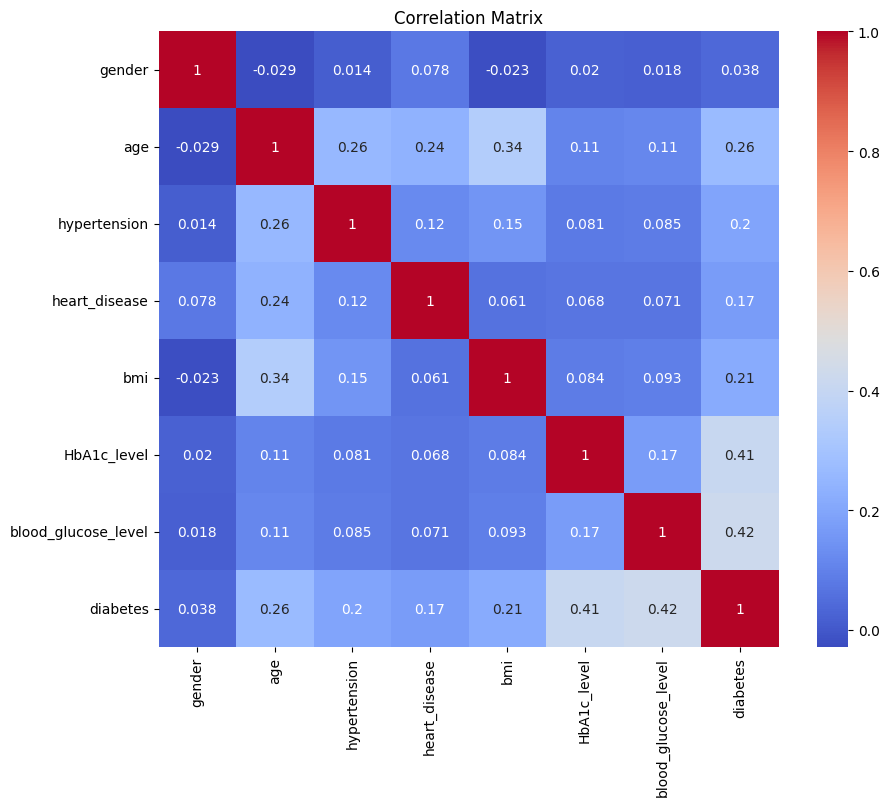

In [109]:
# Correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [98]:
df.head()

,gender,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,25.19,6.6,140,0
1,0,54.0,0,0,27.32,6.6,80,0
2,1,28.0,0,0,27.32,5.7,158,0
3,0,36.0,0,0,23.45,5.0,155,0
4,1,76.0,1,1,20.14,4.8,155,0


In [99]:
# Define X (features) and y (target)
X = df.drop('diabetes', axis=1)  # Features
y = df['diabetes']  # Target

In [100]:
# scalling data
from sklearn.preprocessing import StandardScaler

# Scaling the numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


#Split Data into Training and Testing Sets

In [101]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [102]:
X_train.shape

(76916, 7)

# Train and Evaluate Models

In [103]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [112]:
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

# Define models
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'SVM': SVC(),
    'XGBoost': XGBClassifier()
}

# Dictionary to store model metrics
model_metrics = {
    'Model': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': []
}

# Train, predict, and evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Calculate accuracy, precision, recall, and F1-score
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')  # 'weighted' for multi-class
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Append results to the metrics dictionary
    model_metrics['Model'].append(name)
    model_metrics['Accuracy'].append(accuracy)
    model_metrics['Precision'].append(precision)
    model_metrics['Recall'].append(recall)
    model_metrics['F1-Score'].append(f1)

# Create a DataFrame for better visualization
metrics_df = pd.DataFrame(model_metrics)

# Display the table
print(metrics_df)


                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.956578   0.953891  0.956578  0.953472
1        Random Forest  0.967499   0.966462  0.967499  0.965382
2        Decision Tree  0.949506   0.950541  0.949506  0.949990
3                  SVM  0.961362   0.961982  0.961362  0.956834
4              XGBoost  0.970047   0.969931  0.970047  0.967757


In [117]:
metrics_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.956578,0.953891,0.956578,0.953472
1,Random Forest,0.967499,0.966462,0.967499,0.965382
2,Decision Tree,0.949506,0.950541,0.949506,0.949990
3,SVM,0.961362,0.961982,0.961362,0.956834
4,XGBoost,0.970047,0.969931,0.970047,0.967757


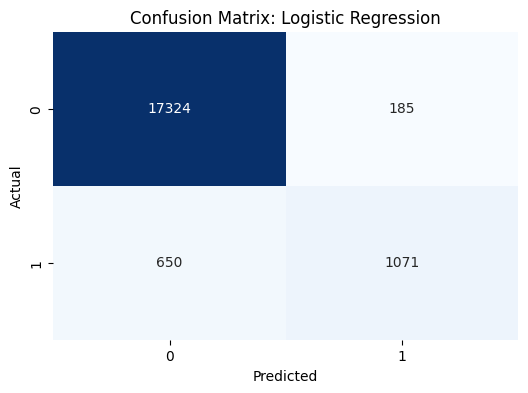

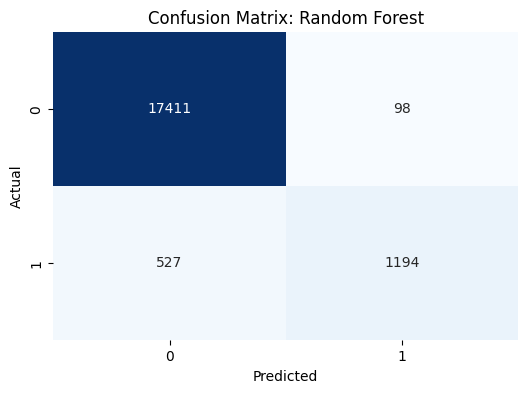

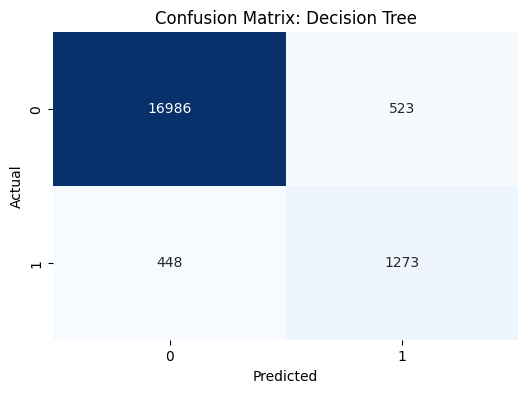

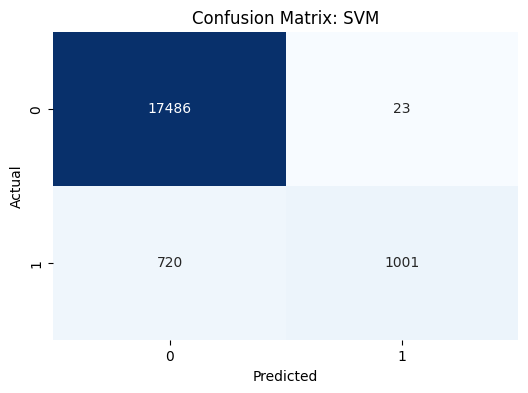

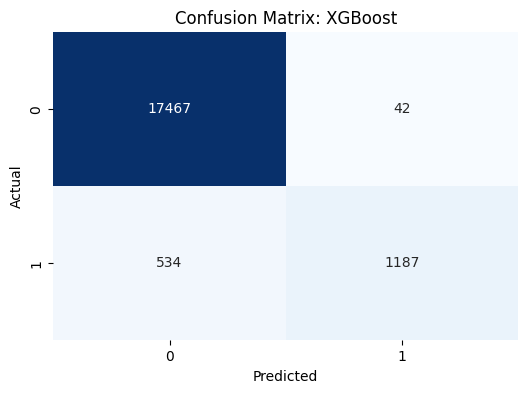

In [113]:
from sklearn.metrics import confusion_matrix

# Function to plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix: {title}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# For each model, we compute the confusion matrix and plot it
for name, model in models.items():
    y_pred = model.predict(X_test)
    plot_confusion_matrix(y_test, y_pred, name)

# Plot Comparison Graph for Model Accuracy

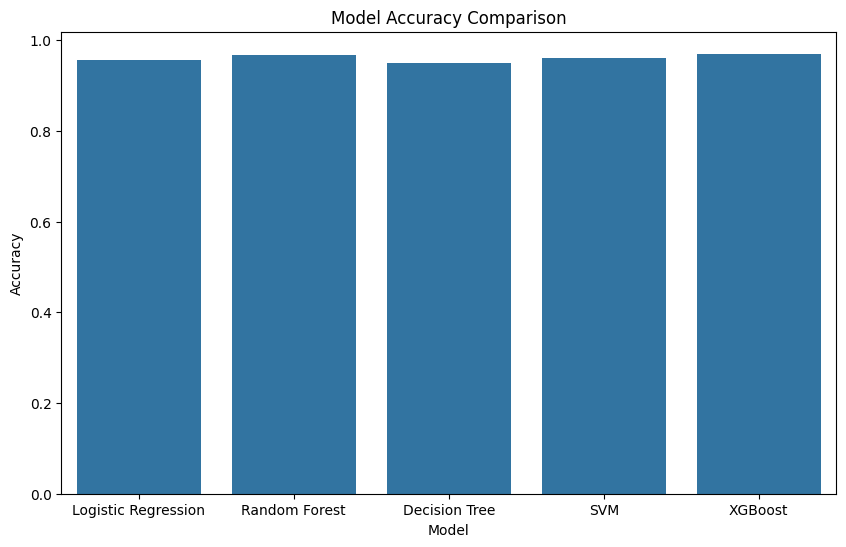

In [114]:
plt.figure(figsize=(10, 6))
sns.barplot(x=list(model_accuracies.keys()), y=list(model_accuracies.values()))
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.show()

#Best Model and Save It

In [115]:
import joblib

# Find the best model based on accuracy
best_model_name = max(model_accuracies, key=model_accuracies.get)
best_model = models[best_model_name]

# Save the best model
joblib.dump(best_model, 'best_diabetes_model.pkl')

print(f"The best model is: {best_model_name} with accuracy: {model_accuracies[best_model_name]:.2f}")


The best model is: XGBoost with accuracy: 0.97
